In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import pandas as pd

In [2]:
wind_data = pd.read_csv('../data/raw/wind_cap_loc_cleaned.csv')
lat = wind_data['Latitude']
long = wind_data['Longitude']

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

In [4]:
lats = wind_data['Latitude'].to_numpy()
lons = wind_data['Longitude'].to_numpy()

cap = wind_data['Installed Capacity (MWelec)'].to_numpy()

In [5]:
def plot_map():
    fig = plt.figure(figsize=(9,10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    ax.set_extent([-9, 3, 49, 61], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False

    return fig, ax

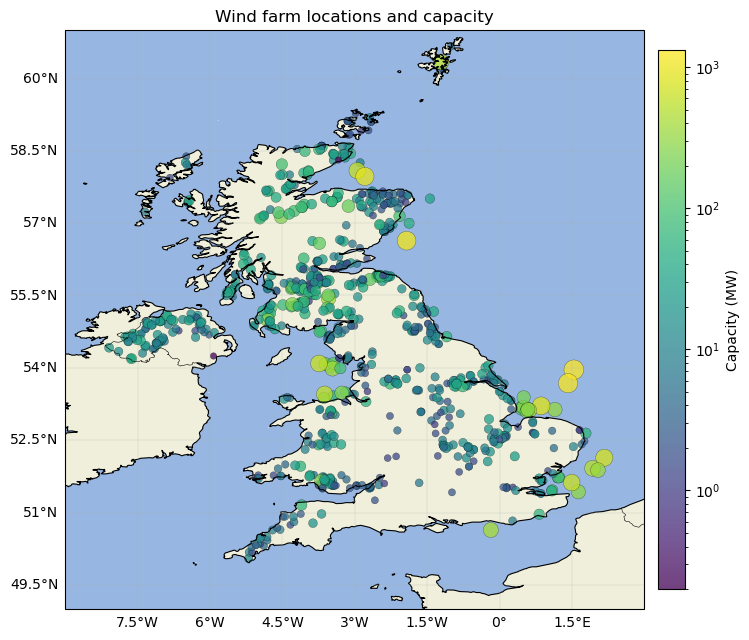

In [6]:
fig, ax = plot_map()

sizes = 20 + 180 * (np.sqrt(cap) / np.sqrt(np.nanmax(cap) if np.nanmax(cap) > 0 else 1))

norm = mcolors.LogNorm(
    vmin=np.nanmin(cap[cap > 0]),   # log can't handle 0
    vmax=np.nanmax(cap)
)

sc = ax.scatter(
    lons, lats,
    s=sizes,
    c=cap,               
    cmap='viridis',
    norm=norm,
    alpha=0.75,
    edgecolors='k',
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Capacity (MW)')

ax.set_title('Wind farm locations and capacity')
plt.show()

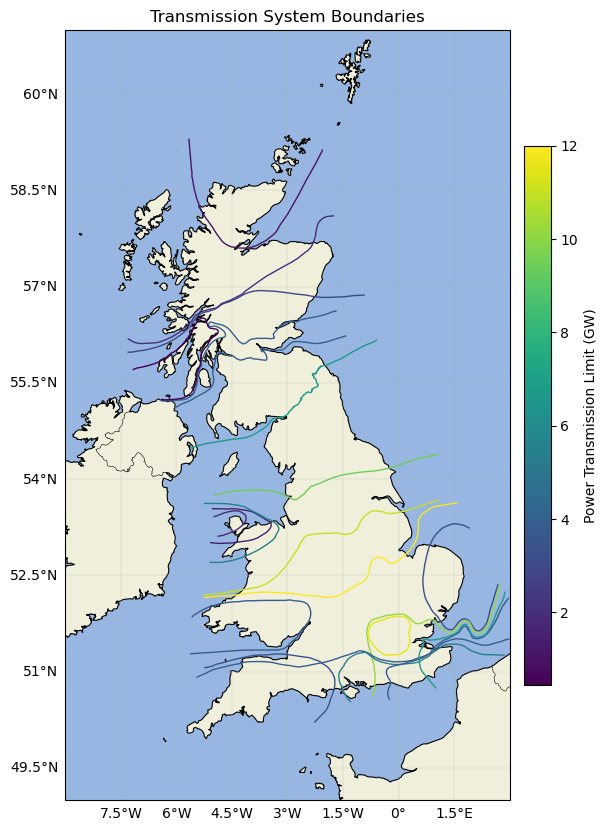

In [7]:
import geopandas as gpd
from shapely import wkt

transmission_boundaries_df = pd.read_csv("../data/raw/transmission_boundaries.csv")
transmission_boundaries_df["geometry"] = transmission_boundaries_df["geometry"].apply(wkt.loads)
transmission_boundaries_gdf = gpd.GeoDataFrame(transmission_boundaries_df, geometry="geometry", crs="EPSG:4326")

fig, ax = plot_map()

transmission_boundaries_gdf.plot(
    ax=ax,
    column="Limit GW",
    cmap="viridis",
    linewidth=1.0,
    legend=False,
    transform=ccrs.PlateCarree()
)


sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=transmission_boundaries_gdf["Limit GW"].min(), vmax=transmission_boundaries_gdf["Limit GW"].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Power Transmission Limit (GW)')

plt.title("Transmission System Boundaries")
plt.show()


In [8]:
from shapely.geometry import LineString, MultiLineString
from shapely.ops import unary_union, polygonize


def extend_linestring(ls: LineString, extend_m=30000) -> LineString:
  
    coords = list(ls.coords)
    if len(coords) < 2:
        return ls

    x0, y0 = coords[0]
    x1, y1 = coords[1]
    v0 = np.array([x0 - x1, y0 - y1], dtype=float)
    n0 = np.linalg.norm(v0)
    if n0 == 0:
        v0 = np.array([0.0, 0.0])
    else:
        v0 /= n0


    xe, ye = coords[-1]
    xprev, yprev = coords[-2]
    v1 = np.array([xe - xprev, ye - yprev], dtype=float)
    n1 = np.linalg.norm(v1)
    if n1 == 0:
        v1 = np.array([0.0, 0.0])
    else:
        v1 /= n1

    new_start = (x0 + extend_m * v0[0], y0 + extend_m * v0[1])
    new_end   = (xe + extend_m * v1[0], ye + extend_m * v1[1])

    return LineString([new_start] + coords + [new_end])


def clip_to_frame_as_lines(geom, frame_poly):
    
    if geom.geom_type == "LineString":
        ext = extend_linestring(geom)
        return ext.intersection(frame_poly)

    if geom.geom_type == "MultiLineString":
        parts = []
        for seg in geom.geoms:
            ext = extend_linestring(seg)
            inter = ext.intersection(frame_poly)
            if not inter.is_empty:
                parts.append(inter)
        if len(parts) == 0:
            return geom.intersection(frame_poly)
        return unary_union(parts)

    return geom.intersection(frame_poly)


def bounds_are_finite(g):
    if g is None or g.is_empty:
        return False
    minx, miny, maxx, maxy = g.bounds
    return np.isfinite([minx, miny, maxx, maxy]).all()



gdf_m = transmission_boundaries_gdf.to_crs(epsg=27700)


url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url).to_crs(epsg=27700)
gb = world[world["ISO_A3"] == "GBR"]

pad_m = 5000  
frame_poly = gb.unary_union.buffer(pad_m)  
frame_line = frame_poly.boundary            


cut_lines = []
for geom in gdf_m.geometry:
    clipped = clip_to_frame_as_lines(geom, frame_poly)
    if not clipped.is_empty:
        cut_lines.append(clipped)


linework = cut_lines + [frame_line]


merged = unary_union(linework)
polys = list(polygonize(merged))

areas_m = gpd.GeoDataFrame(geometry=polys, crs="EPSG:27700")


areas_m["geometry"] = areas_m.geometry.intersection(frame_poly)
areas_m = areas_m[~areas_m.geometry.is_empty & areas_m.geometry.notna()].copy()


areas_m = areas_m[areas_m.geometry.apply(bounds_are_finite)].copy()


areas = areas_m.to_crs(epsg=4326)

/tmp/ipykernel_1993/4180481393.py:72: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  frame_poly = gb.unary_union.buffer(pad_m)


In [9]:
offshore = pd.read_csv('../data/raw/offshore_wind_bus_locations.csv')

In [10]:
wind_gdf = gpd.GeoDataFrame(
    wind_data,
    geometry=gpd.points_from_xy(wind_data["Longitude"], wind_data["Latitude"]),
    crs="EPSG:4326"
)

In [12]:
offshore_gdf = gpd.GeoDataFrame(
    offshore,
    geometry=gpd.points_from_xy(offshore["bus_lon"], offshore["bus_lat"]),
    crs="EPSG:4326"
)

In [13]:
areas = areas.to_crs(epsg=4326)

areas = areas.reset_index(drop=True)
areas["area_id"] = areas.index

In [14]:
wind_with_boundary = gpd.sjoin(
    wind_gdf,
    areas[["area_id", "geometry"]],
    how="left",
    predicate="within"
)

In [15]:
offshore_with_boundary = gpd.sjoin(
    offshore_gdf,
    areas[["area_id", "geometry"]],
    how="left",
    predicate="within"
)

In [16]:
wind_capacity_per_boundary = (
    wind_with_boundary
    .groupby("area_id")["Installed Capacity (MWelec)"]
    .sum()
)

In [17]:
offshore_capacity_per_boundary = (
    offshore_with_boundary
    .groupby("area_id")["wind_mw"]
    .sum()
)

In [18]:
capacity_per_boundary = wind_capacity_per_boundary.add(offshore_capacity_per_boundary, fill_value=0)

In [19]:
cap_df = capacity_per_boundary.rename("wind_mw").reset_index()  

areas_cap = areas.merge(cap_df, on="area_id", how="left")
areas_cap["wind_mw"] = areas_cap["wind_mw"].fillna(0.0)

In [20]:
areas_cap["wind_gw"] = areas_cap["wind_mw"] / 1000.0
areas_cap["label_pt"] = areas_cap.geometry.representative_point()

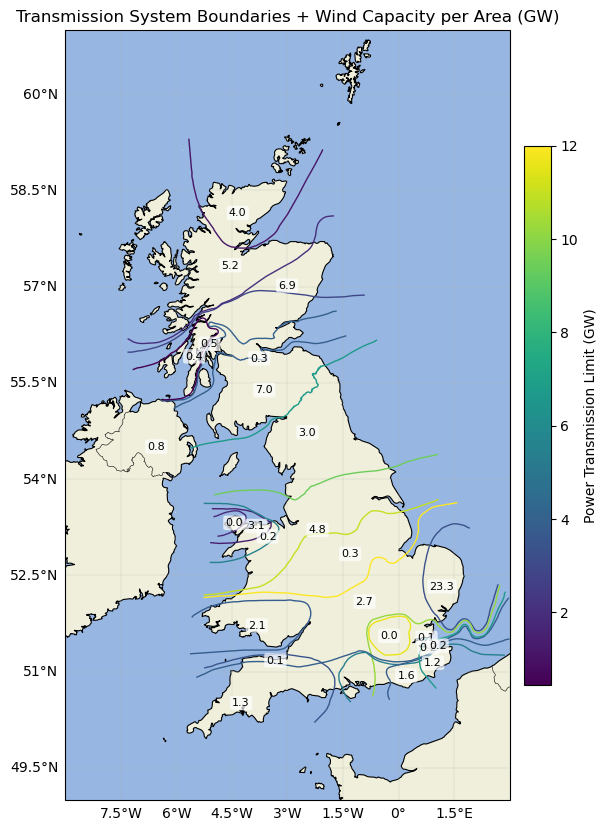

In [21]:
transmission_boundaries_df = pd.read_csv("../data/raw/transmission_boundaries.csv")
transmission_boundaries_df["geometry"] = transmission_boundaries_df["geometry"].apply(wkt.loads)
transmission_boundaries_gdf = gpd.GeoDataFrame(
    transmission_boundaries_df, geometry="geometry", crs="EPSG:4326"
)

fig, ax = plot_map()

transmission_boundaries_gdf.plot(
    ax=ax,
    column="Limit GW",
    cmap="viridis",
    linewidth=1.0,
    legend=False,
    transform=ccrs.PlateCarree()
)

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=transmission_boundaries_gdf["Limit GW"].min(),
        vmax=transmission_boundaries_gdf["Limit GW"].max()
    )
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.02, shrink=0.7)
cbar.set_label("Power Transmission Limit (GW)")

for _, row in areas_cap.iterrows():
    x = row["label_pt"].x
    y = row["label_pt"].y
    val = row["wind_gw"]  

    if val <= 0:
        continue

    ax.text(
        x, y,
        f"{val:.1f}",             
        transform=ccrs.PlateCarree(),
        ha="center", va="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

plt.title("Transmission System Boundaries + Wind Capacity per Area (GW)")
plt.show()

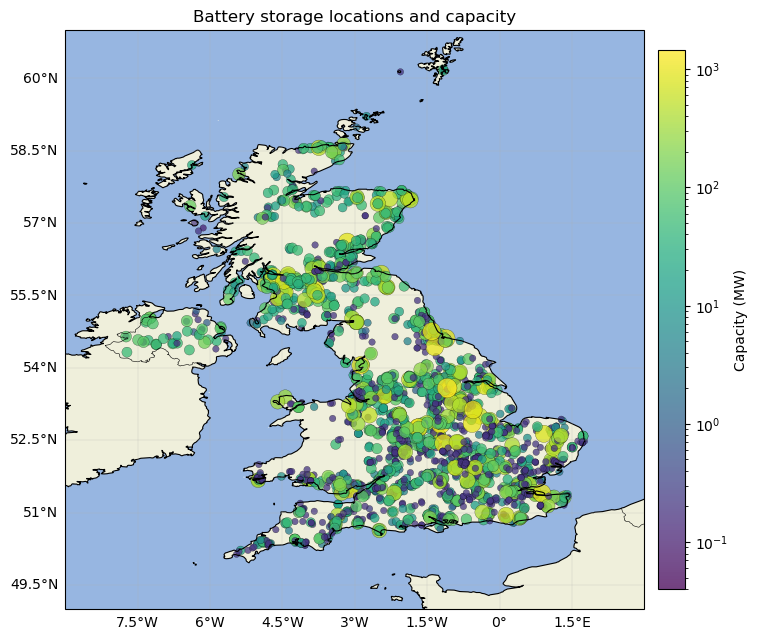

In [22]:
battery_storage_df = pd.read_csv("../data/raw/battery_storage_locations.csv")
bat_lats = battery_storage_df["Latitude"]
bat_lons = battery_storage_df["Longitude"]
bat_cap = battery_storage_df["Installed Capacity (MWelec)"]


fig, ax = plot_map()

sizes = 20 + 180 * (np.sqrt(bat_cap) / np.sqrt(np.nanmax(bat_cap) if np.nanmax(bat_cap) > 0 else 1))

norm = mcolors.LogNorm(
    vmin=np.nanmin(bat_cap[bat_cap > 0]),   # log can't handle 0
    vmax=np.nanmax(bat_cap)
)

sc = ax.scatter(
    bat_lons, bat_lats,
    s=sizes,
    c=bat_cap,               
    cmap='viridis',
    norm=norm,
    alpha=0.75,
    edgecolors='k',
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Capacity (MW)')

ax.set_title('Battery storage locations and capacity')
plt.show()


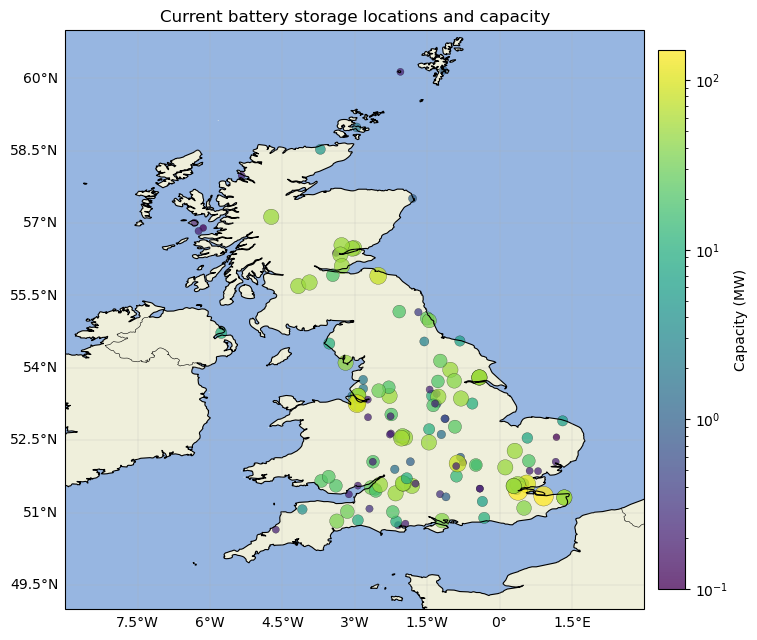

In [23]:
battery_storage_df = pd.read_csv("../data/raw/battery_storage_locations.csv")
current_battery_storage_df = battery_storage_df[battery_storage_df["Development Status (short)"] == "Operational"]
bat_lats = current_battery_storage_df["Latitude"]
bat_lons = current_battery_storage_df["Longitude"]
bat_cap = current_battery_storage_df["Installed Capacity (MWelec)"]


fig, ax = plot_map()

sizes = 20 + 180 * (np.sqrt(bat_cap) / np.sqrt(np.nanmax(bat_cap) if np.nanmax(bat_cap) > 0 else 1))

norm = mcolors.LogNorm(
    vmin=np.nanmin(bat_cap[bat_cap > 0]),   # log can't handle 0
    vmax=np.nanmax(bat_cap)
)

sc = ax.scatter(
    bat_lons, bat_lats,
    s=sizes,
    c=bat_cap,               
    cmap='viridis',
    norm=norm,
    alpha=0.75,
    edgecolors='k',
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Capacity (MW)')

ax.set_title('Current battery storage locations and capacity')
plt.show()

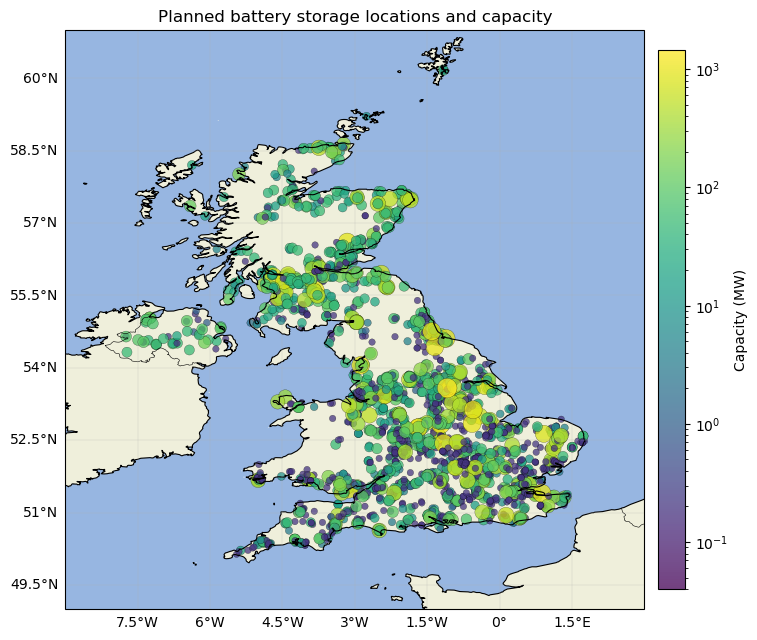

In [24]:
battery_storage_df = pd.read_csv("../data/raw/battery_storage_locations.csv")
planned_battery_storage_df = battery_storage_df[battery_storage_df["Development Status (short)"] != "Operational"]
bat_lats = planned_battery_storage_df["Latitude"]
bat_lons = planned_battery_storage_df["Longitude"]
bat_cap = planned_battery_storage_df["Installed Capacity (MWelec)"]


fig, ax = plot_map()

sizes = 20 + 180 * (np.sqrt(bat_cap) / np.sqrt(np.nanmax(bat_cap) if np.nanmax(bat_cap) > 0 else 1))

norm = mcolors.LogNorm(
    vmin=np.nanmin(bat_cap[bat_cap > 0]),   # log can't handle 0
    vmax=np.nanmax(bat_cap)
)

sc = ax.scatter(
    bat_lons, bat_lats,
    s=sizes,
    c=bat_cap,               
    cmap='viridis',
    norm=norm,
    alpha=0.75,
    edgecolors='k',
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Capacity (MW)')

ax.set_title('Planned battery storage locations and capacity')
plt.show()